# Trabajo Práctico Integrador – Módulo II
## Opción 2 — Preprocesamiento con `ColumnTransformer` + `Pipeline`

**Caso:** análisis de clientes de una empresa de servicios de telecomunicaciones.

Este cuaderno resuelve el **mismo trabajo práctico integrador** que
`TP_Integrador_Analisis_Clientes_Telecomunicaciones.ipynb`, pero con un enfoque técnico distinto
para el preprocesamiento:

| | Cuaderno | Imputación | Codificación |
|---|---|---|---|
| **Opción 1** | `TP_Integrador_Analisis_Clientes_Telecomunicaciones.ipynb` | `fillna()` manual | `pd.get_dummies()` |
| **Opción 2** | *este cuaderno* | `SimpleImputer` | `OneHotEncoder` |

En la Opción 1 calculamos las medianas y modas a mano, las aplicamos con `fillna()` y codificamos
con `pd.get_dummies()`, acordándonos de alinear las columnas de test con `reindex()`. Acá, en
cambio, todo eso vive dentro de un único objeto `Pipeline` que se entrena con `.fit()` y se aplica
con `.predict()`.

> **Ya comprobamos que ambos enfoques son equivalentes** (mismas predicciones, mismo R²).
> Los mantenemos en cuadernos separados para que cada enfoque se pueda leer completo y de corrido,
> sin alternar entre dos formas de resolver lo mismo.

### Por qué conviene el `Pipeline`

1. **Imposibilita la fuga de datos por descuido.** El preprocesador se ajusta *solo* con los datos
   que recibe en `.fit()`. No hay forma de contaminarlo con test sin darse cuenta.
2. **Elimina el bug clásico del `reindex`.** `OneHotEncoder(handle_unknown='ignore')` resuelve solo
   el problema de las categorías que aparecen en un conjunto y no en el otro.
3. **Un cliente nuevo se predice en una línea.** No hay que reconstruir el preprocesamiento paso a
   paso ni recordar qué valores se usaron para imputar.
4. **Es requisito para hacer bien la validación cruzada.** Al usar `GridSearchCV` sobre un
   `Pipeline`, el preprocesamiento se reajusta dentro de cada *fold*, como corresponde.

### Preguntas del caso
1. ¿Podemos estimar cuánto facturará un cliente durante el año?
2. ¿Podemos identificar clientes con riesgo de abandonar el servicio?
3. ¿Existen diferentes perfiles de clientes dentro de la base?

## Archivos y variables

Archivo de trabajo: **`dataset_clientes_comunicaciones.csv`**

> Utilizá el archivo CSV provisto junto con este cuaderno.

Variables principales:

- `id_cliente`: identificador único del cliente.
- `edad`: edad en años.
- `antiguedad_meses`: cantidad de meses como cliente de la empresa.
- `cargo_mensual`: importe mensual facturado por los servicios contratados.
- `cantidad_servicios`: cantidad de servicios contratados.
- `consultas_soporte`: cantidad de consultas realizadas al área de soporte.
- `reclamos_ultimo_anio`: cantidad de reclamos registrados durante el último año.
- `horas_uso_mensual`: horas de utilización mensual de los servicios.
- `tipo_contrato`: Mensual, Anual o Bianual.
- `medio_pago`: medio de pago habitual.
- `satisfaccion`: puntaje de satisfacción del cliente, en una escala de 1 a 10, obtenido a partir de encuestas.
- `gasto_anual`: facturación total del cliente durante el último año. Variable objetivo sugerida para regresión.
- `abandono`: 0 = permanece; 1 = abandona. Variable objetivo para clasificación.

> Las variables representan información que la empresa podría obtener de sus sistemas de clientes, facturación, soporte y encuestas de satisfacción.

## 1. Importación de librerías

In [1]:
# Importá aquí las librerías necesarias.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, silhouette_score)

# El corazón de la Opción 2: preprocesamiento declarativo de scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Carga y exploración inicial

1. Cargá el CSV.
2. Mostrá las primeras filas.
3. Informá cantidad de filas y columnas.
4. Revisá tipos de datos.
5. Calculá estadísticas descriptivas.
6. Contá valores faltantes por variable.
7. Analizá la distribución de `abandono`.

In [2]:
# Cargá el dataset en un DataFrame llamado df
df = pd.read_csv('dataset_clientes_comunicaciones.csv')

In [3]:
# Primeras filas, shape, info y describe
display(df.head())
print(f'\nFilas: {df.shape[0]}  Columnas: {df.shape[1]}')
df.info()
df.describe().T.round(2)

,id_cliente,edad,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,tipo_contrato,medio_pago,satisfaccion,gasto_anual,abandono
0,C1001,30,23,57300,1,6,3,45.3,Anual,Tarjeta,2.7,568000,1
1,C1002,49,42,128000,4,1,1,78.1,Anual,Transferencia,7.9,1549000,0
2,C1003,52,89,120100,3,0,1,55.4,Bianual,Debito automatico,7.8,1513000,0
3,C1004,34,21,48600,1,4,1,37.0,Anual,Efectivo,3.9,632000,1
4,C1005,26,4,67600,3,1,0,37.5,Mensual,Tarjeta,4.6,926000,0



Filas: 1000  Columnas: 13
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            1000 non-null   str    
 1   edad                  1000 non-null   int64  
 2   antiguedad_meses      1000 non-null   int64  
 3   cargo_mensual         1000 non-null   int64  
 4   cantidad_servicios    1000 non-null   int64  
 5   consultas_soporte     1000 non-null   int64  
 6   reclamos_ultimo_anio  1000 non-null   int64  
 7   horas_uso_mensual     988 non-null    float64
 8   tipo_contrato         1000 non-null   str    
 9   medio_pago            990 non-null    str    
 10  satisfaccion          982 non-null    float64
 11  gasto_anual           1000 non-null   int64  
 12  abandono              1000 non-null   int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 101.7 KB


,count,mean,std,min,25%,50%,75%,max
edad,1000.0,37.68,11.97,18.0,28.00,37.0,47.00,70.0
antiguedad_meses,1000.0,38.51,28.06,1.0,14.00,35.0,60.00,117.0
cargo_mensual,1000.0,104002.30,32330.47,25000.0,77875.00,107200.0,129200.00,185000.0
cantidad_servicios,1000.0,2.92,1.30,1.0,2.00,3.0,4.00,6.0
consultas_soporte,1000.0,3.06,2.43,0.0,1.00,3.0,4.00,13.0
reclamos_ultimo_anio,1000.0,1.46,1.73,0.0,0.00,1.0,2.00,10.0
horas_uso_mensual,988.0,63.38,26.03,5.0,44.08,64.9,81.82,136.4
satisfaccion,982.0,6.68,1.97,1.0,5.30,7.0,8.10,10.0
gasto_anual,1000.0,1331074.00,412383.60,280000.0,1026000.00,1349500.0,1632250.00,2495000.0
abandono,1000.0,0.34,0.47,0.0,0.00,0.0,1.00,1.0


Valores faltantes por columna:
id_cliente               0
edad                     0
antiguedad_meses         0
cargo_mensual            0
cantidad_servicios       0
consultas_soporte        0
reclamos_ultimo_anio     0
horas_uso_mensual       12
tipo_contrato            0
medio_pago              10
satisfaccion            18
gasto_anual              0
abandono                 0
dtype: int64

Distribución de abandono:
abandono
0    660
1    340
Name: count, dtype: int64
abandono
0    66.0 %
1    34.0 %
Name: count, dtype: str


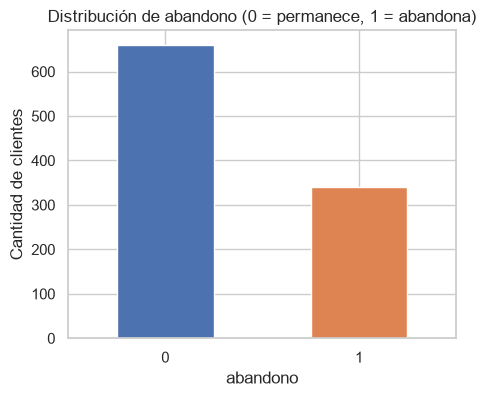

In [4]:
# Valores faltantes y distribución de abandono
print('Valores faltantes por columna:')
print(df.isnull().sum())

print('\nDistribución de abandono:')
conteo_abandono = df['abandono'].value_counts()
print(conteo_abandono)
print((conteo_abandono / len(df) * 100).round(1).astype(str) + ' %')

plt.figure(figsize=(5, 4))
conteo_abandono.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Distribución de abandono (0 = permanece, 1 = abandona)')
plt.xticks(rotation=0)
plt.ylabel('Cantidad de clientes')
plt.show()

### Interpretación 1
Respondé con tus palabras:

- ¿El dataset está completamente limpio?
- ¿Qué variables presentan valores faltantes?
- ¿La variable `abandono` está balanceada?
- ¿Por qué un desbalance puede afectar la interpretación del Accuracy?

**Respuesta:**

El dataset no está completamente limpio: tiene 1000 filas y 3 columnas con valores faltantes: `horas_uso_mensual` (12 nulos), `medio_pago` (10 nulos) y `satisfaccion` (18 nulos). El resto de las columnas no tiene nulos.

La variable `abandono` **no** está balanceada: 660 clientes permanecen (66 %) contra 340 que abandonan (34 %). No es un desbalance tan extremo como el 93 %/7 % típico de otros datasets de riesgo, pero igual conviene tenerlo en cuenta.

Un desbalance afecta al Accuracy porque esta métrica solo mide el porcentaje total de aciertos, sin distinguir en qué clase se equivoca el modelo. Con una proporción 66/34, un modelo que prediga "permanece" para *todos* los clientes ya acertaría el 66 % de las veces sin haber aprendido nada útil sobre quién realmente abandona. Por eso, para este problema, conviene mirar también Precision, Recall y F1 (especialmente el Recall de la clase `abandono=1`), y no solo el Accuracy.

## 3. Preparación de los datos

### 3.1 `id_cliente`
Explicá por qué `id_cliente` no debería utilizarse como predictor.

### 3.2 Valores faltantes
Elegí una estrategia razonable según el tipo de variable. Para los modelos se recomienda que la imputación se **ajuste solo con datos de entrenamiento**, para evitar fuga de información.

### Interpretación 2
- ¿Qué representa `id_cliente`?
- ¿Por qué no debe usarse como predictor?
- ¿Qué criterio usarías para imputar variables numéricas y categóricas?

**Respuesta:**

`id_cliente` es un identificador único (`C1001`, `C1002`, ...) que la empresa asigna administrativamente a cada cliente — no describe ninguna característica real de su comportamiento, contrato o uso del servicio.

No debe usarse como predictor porque no tiene relación causal ni estadística real con `gasto_anual` o `abandono`: es solo una etiqueta arbitraria. Si un modelo "aprendiera" algo a partir del ID, sería puro ruido o una coincidencia del orden en que se cargaron los clientes — no algo que vaya a generalizar a clientes nuevos (que tendrán un ID distinto y nunca antes visto).

Para imputar los valores faltantes:
- **Variables numéricas** (`horas_uso_mensual`, `satisfaccion`): mediana, calculada únicamente con los datos de entrenamiento. Se prefiere la mediana sobre la media porque es más robusta ante outliers.
- **Variables categóricas** (`medio_pago`): moda (el valor más frecuente), también calculada solo con entrenamiento.

En ambos casos, el valor de imputación se calcula **una sola vez sobre `X_train`** y se aplica igual a `X_train` y a `X_test` — si lo calculáramos usando también `X_test`, estaríamos filtrando información del conjunto de prueba hacia el entrenamiento (fuga de datos), lo mismo que se explica más abajo para el escalado del KNN.

# PARTE A — REGRESIÓN
## 4. ¿Cuánto facturará un cliente durante el año?

Variable objetivo: **`gasto_anual`**.

No uses `id_cliente` ni `abandono` como predictores.

### 4.1 Definir X e y y dividir entrenamiento/prueba
Usá `test_size=0.20` y `random_state=42`.

In [5]:
# Definí X_reg e y_reg y realizá train_test_split
predictoras = ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
               'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual',
               'tipo_contrato', 'medio_pago', 'satisfaccion']
num_cols = ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
            'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion']
cat_cols = ['tipo_contrato', 'medio_pago']

X_reg = df[predictoras]
y_reg = df['gasto_anual']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print('X_reg_train:', X_reg_train.shape)
print('X_reg_test :', X_reg_test.shape)

X_reg_train: (800, 10)
X_reg_test : (200, 10)


### 4.2 Preprocesamiento

- Variables numéricas: imputación por mediana.
- Variables categóricas: imputación por moda + One-Hot Encoding.

El enunciado sugiere: *"Podés usar `ColumnTransformer` y `Pipeline`"*. Eso es exactamente lo que
hacemos acá.

**Cómo se lee la estructura.** Un `ColumnTransformer` aplica una transformación distinta según el
tipo de columna, y las ejecuta en paralelo:

- rama `'num'` → `SimpleImputer(strategy='median')` sobre `num_cols`;
- rama `'cat'` → un `Pipeline` interno de dos pasos (`SimpleImputer(strategy='most_frequent')` y
  después `OneHotEncoder`) sobre `cat_cols`.

Ese `ColumnTransformer` se encadena con el modelo en un `Pipeline` final. Al llamar
`.fit(X_reg_train, y_reg_train)`, primero el preprocesador **aprende** medianas, modas y categorías
usando solo `X_reg_train`, transforma, y recién entonces entrena la `LinearRegression`. Al llamar
`.predict(X_reg_test)`, reaplica automáticamente lo aprendido.

Dos detalles que en la Opción 1 había que resolver a mano:

- `drop='first'` cumple el mismo rol que `drop_first=True` en `get_dummies`: evita una columna
  redundante (si no es Bianual ni Mensual, es Anual).
- `handle_unknown='ignore'` reemplaza al `reindex()`: si aparece una categoría nunca vista en
  entrenamiento, la codifica como todos ceros en vez de romperse.

In [6]:
# Construí el preprocesamiento y el modelo de LinearRegression

preprocesador_reg = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), cat_cols)
])

modelo_reg = Pipeline([
    ('preprocesamiento', preprocesador_reg),
    ('regresor', LinearRegression())
])

# Entrenamos directamente sobre X_reg_train "crudo": con nulos y columnas de
# texto incluidas. El Pipeline se encarga de todo el preprocesamiento.
modelo_reg.fit(X_reg_train, y_reg_train)

# Así quedaron las columnas después del preprocesamiento
nombres_features = modelo_reg.named_steps['preprocesamiento'].get_feature_names_out()
print('Columnas generadas por el preprocesador:', len(nombres_features))
for n in nombres_features:
    print('  -', n)

Columnas generadas por el preprocesador: 13
  - num__edad
  - num__antiguedad_meses
  - num__cargo_mensual
  - num__cantidad_servicios
  - num__consultas_soporte
  - num__reclamos_ultimo_anio
  - num__horas_uso_mensual
  - num__satisfaccion
  - cat__tipo_contrato_Bianual
  - cat__tipo_contrato_Mensual
  - cat__medio_pago_Efectivo
  - cat__medio_pago_Tarjeta
  - cat__medio_pago_Transferencia


### 4.3 Entrenamiento y métricas
Calculá **MAE, MSE, RMSE y R²**.

In [7]:
# Entrená el modelo, predecí y calculá las métricas
# Nota: modelo_reg ya fue entrenado arriba con .fit() — el Pipeline entrena
# el preprocesamiento y el regresor en una sola llamada.

y_reg_pred = modelo_reg.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = mse ** 0.5
r2 = modelo_reg.score(X_reg_test, y_reg_test)

print(f'MAE  : {mae:,.2f}')
print(f'MSE  : {mse:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')

MAE  : 72,478.79


MSE  : 8,549,179,138.68
RMSE : 92,461.77
R²   : 0.9504


### Interpretación 3
- ¿Qué representa el MAE en este problema?
- ¿Qué indica el RMSE?
- ¿Qué significa R²?
- ¿Considerás razonable el modelo? Justificá con las métricas.
- ¿Por qué Accuracy no corresponde para evaluar esta tarea?

**Respuesta:**

El **MAE** (72.479) significa que, en promedio, la predicción del modelo se aleja del `gasto_anual` real del cliente en aproximadamente $72.479. Está en la misma unidad que la variable objetivo (pesos/dólares de facturación), así que es fácil de leer directamente.

El **RMSE** (92.462) también está en esa misma unidad, pero al elevar los errores al cuadrado antes de promediar, penaliza más los errores grandes. Que el RMSE sea más alto que el MAE nos dice que hay algunos clientes donde el modelo se equivoca bastante más que el promedio (errores grandes puntuales), no que se equivoque de forma pareja en todos los casos.

El **R²** (0.9504) indica que el modelo explica aproximadamente el 95 % de la variabilidad del `gasto_anual` a partir de las variables predictoras. Es un valor alto.

Considerando que el `cargo_mensual` promedio de los clientes ronda los $100.000 (y `gasto_anual` es del orden de $1.000.000+ para muchos casos), un error promedio de ~$72.000 representa un porcentaje moderado del valor típico — el modelo es razonable, aunque no perfecto: para decisiones que dependan de una estimación muy precisa por cliente individual, ese margen de error debería tenerse en cuenta.

El Accuracy no corresponde acá porque es una métrica para **clasificación** (mide qué porcentaje de etiquetas categóricas se predijeron correctamente, un acierto binario "sí/no"). `gasto_anual` es una variable numérica continua: no tiene sentido preguntar si la predicción fue "correcta" o "incorrecta" en términos absolutos, sino **cuánto** se alejó del valor real — para eso existen MAE, MSE, RMSE y R².

# PARTE B — CLASIFICACIÓN
## 5. ¿Qué clientes podrían abandonar?

Variable objetivo: **`abandono`**.

No uses como predictores: `id_cliente`, `abandono` ni `gasto_anual`.

### 5.1 Data Leakage
Explicá por qué `gasto_anual` podría producir **fuga de información** si representa información conocida recién al finalizar el período que queremos predecir.

**Respuesta:**

`gasto_anual` es la facturación **total del año**, es decir, un dato que solo se termina de conocer cuando el año ya cerró — y el abandono, si ocurre, probablemente pasó *durante* ese año, no después. Un cliente que abandona a mitad de año probablemente tenga un `gasto_anual` mucho más bajo (dejó de facturar antes), simplemente **como consecuencia** de haber abandonado, no como una causa que lo explique de antemano.

Si usáramos `gasto_anual` como predictor de `abandono`, el modelo aprendería una relación que en la práctica no podríamos usar: en el momento real en que necesitamos predecir si un cliente va a abandonar (para poder actuar a tiempo, por ejemplo, ofreciéndole una promoción), todavía no sabemos cuál va a ser su `gasto_anual` final, porque eso depende justamente de si abandona o no. Sería usar información "del futuro" (posterior al momento de la predicción) para explicar el pasado — eso es **fuga de información (data leakage)**, y hace que las métricas del modelo se vean artificialmente mejores de lo que realmente serían en un caso de uso real.

### 5.2 Preparar datos
Usá `test_size=0.20`, `random_state=42` y `stratify=y`.

In [8]:
# Definí X_clf, y_clf y realizá train_test_split
X_clf = df[predictoras]
y_clf = df['abandono']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# No hay preprocesamiento manual acá: cada modelo lleva el suyo adentro del Pipeline.
print('X_clf_train:', X_clf_train.shape)
print('X_clf_test :', X_clf_test.shape)
print('Proporción de abandono en train:', y_clf_train.mean().round(3))
print('Proporción de abandono en test :', y_clf_test.mean().round(3))

X_clf_train: (800, 10)
X_clf_test : (200, 10)
Proporción de abandono en train: 0.34
Proporción de abandono en test : 0.34


## 6. Regresión Logística
Preprocesá los datos, entrená y calculá Accuracy, Precision, Recall, F1 y matriz de confusión.

Accuracy : 0.79
Precision: 0.6711
Recall   : 0.75
F1       : 0.7083

              precision    recall  f1-score   support

           0       0.86      0.81      0.84       132
           1       0.67      0.75      0.71        68

    accuracy                           0.79       200
   macro avg       0.77      0.78      0.77       200
weighted avg       0.80      0.79      0.79       200



C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


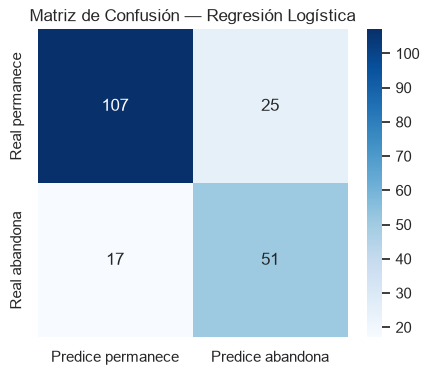

In [9]:
# Modelo de Regresión Logística

# Reutilizamos la MISMA receta de preprocesamiento de la Parte A. Definirla una vez
# y reusarla en todos los modelos es otra ventaja del enfoque declarativo.
def nuevo_preprocesador():
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), cat_cols)
    ])

modelo_log = Pipeline([
    ('preprocesamiento', nuevo_preprocesador()),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
])
modelo_log.fit(X_clf_train, y_clf_train)

pred_log = modelo_log.predict(X_clf_test)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_log), 4))
print('Precision:', round(precision_score(y_clf_test, pred_log), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_log), 4))
print('F1       :', round(f1_score(y_clf_test, pred_log), 4))
print()
print(classification_report(y_clf_test, pred_log))

cm_log = confusion_matrix(y_clf_test, pred_log)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predice permanece', 'Predice abandona'],
            yticklabels=['Real permanece', 'Real abandona'])
plt.title('Matriz de Confusión — Regresión Logística')
plt.show()

### Interpretación 4
- ¿Cuántos abandonos reales detectó correctamente?
- ¿Cuántos clientes que abandonaron fueron clasificados como permanencia?
- ¿Qué métrica refleja especialmente nuestra capacidad de detectar abandonos?

**Respuesta:**

Según la matriz de confusión del conjunto de prueba (68 clientes que realmente abandonaron, de un total de 200):

- El modelo detectó correctamente **51 abandonos reales** (verdaderos positivos).
- **17 clientes** que sí abandonaron fueron clasificados por error como "permanece" (falsos negativos) — son los casos más costosos para el negocio, porque son clientes en riesgo que el modelo no logró identificar.

La métrica que refleja específicamente esta capacidad es el **Recall** de la clase `abandono=1`: `51 / (51 + 17) = 0.75`. Es decir, el modelo logra detectar el 75 % de los clientes que realmente van a abandonar. El Accuracy general (0.79) no distingue este detalle, porque promedia los aciertos de ambas clases por igual.

## 7. KNN y escalado

KNN utiliza distancias, por eso las variables numéricas deben escalarse. El scaler debe ajustarse **solo con entrenamiento**.

Probá `k = 3, 5, 7, 9, 11`. Para evitar usar el conjunto de prueba para elegir `k`, podés separar una pequeña validación a partir del conjunto de entrenamiento.

Acá el `Pipeline` deja de ser una comodidad y pasa a ser **lo correcto**.

`GridSearchCV` con `cv=5` parte `X_clf_train` en 5 pliegues y, en cada iteración, entrena con 4 y
valida con 1. Si hubiéramos imputado y escalado *antes* de entrar al `GridSearchCV` — como pasa en
la Opción 1 —, la mediana y el `StandardScaler` se habrían calculado con los 5 pliegues juntos,
incluido el que en cada vuelta hace de validación. Eso es fuga de datos dentro de la validación
cruzada, y hace que el Accuracy de CV se vea mejor de lo que realmente es.

Metiendo **todo** el preprocesamiento dentro del `Pipeline`, scikit-learn lo reajusta desde cero en
cada pliegue. El orden de los pasos es: preprocesar (imputar + codificar) → escalar → clasificar.

In [10]:
# Prepará preprocesamiento con StandardScaler, probá distintos k y elegí uno
pipeline_knn = Pipeline([
    ('preprocesamiento', nuevo_preprocesador()),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {'knn__n_neighbors': [3, 5, 7, 9, 11]}

# Entrenamos sobre X_clf_train crudo: el preprocesamiento se reajusta en cada pliegue.
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_clf_train, y_clf_train)

resultados_k = pd.DataFrame(grid_knn.cv_results_)[['param_knn__n_neighbors', 'mean_test_score']]
print(resultados_k.to_string(index=False))
print()
print('Mejor k:', grid_knn.best_params_['knn__n_neighbors'])
print('Accuracy promedio (validación cruzada):', round(grid_knn.best_score_, 4))

 param_knn__n_neighbors  mean_test_score
                      3          0.80125
                      5          0.80250
                      7          0.78250
                      9          0.78125
                     11          0.79875

Mejor k: 5
Accuracy promedio (validación cruzada): 0.8025


Accuracy : 0.745
Precision: 0.6076
Recall   : 0.7059
F1       : 0.6531


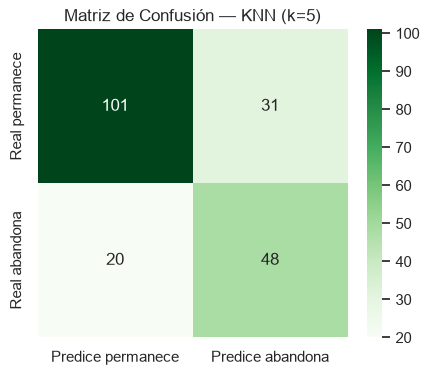

In [11]:
# Entrená el KNN final y calculá métricas + matriz de confusión
modelo_knn = grid_knn.best_estimator_
pred_knn = modelo_knn.predict(X_clf_test)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_knn), 4))
print('Precision:', round(precision_score(y_clf_test, pred_knn), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_knn), 4))
print('F1       :', round(f1_score(y_clf_test, pred_knn), 4))

cm_knn = confusion_matrix(y_clf_test, pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predice permanece', 'Predice abandona'],
            yticklabels=['Real permanece', 'Real abandona'])
plt.title(f"Matriz de Confusión — KNN (k={grid_knn.best_params_['knn__n_neighbors']})")
plt.show()

### Interpretación 5
- ¿Por qué el escalado es importante en KNN?
- ¿Por qué el scaler no debe ajustarse con todos los datos?
- ¿Qué valor de k elegiste y por qué?

**Respuesta:**

KNN clasifica un punto nuevo según sus vecinos más cercanos, y "cercano" se mide con una **distancia** (euclidiana) que combina todas las variables. Si no escalamos, una variable con números grandes como `cargo_mensual` (miles) dominaría completamente el cálculo de distancia frente a una variable como `satisfaccion` (escala 1 a 10), aunque ambas puedan ser igual de relevantes para predecir el abandono. Escalar (con `StandardScaler`, media 0 y desvío 1) hace que todas las variables pesen de forma comparable.

El *scaler* no debe ajustarse con todos los datos porque, si calculáramos la media y el desvío usando también `X_test`, el modelo estaría "viendo" información estadística del conjunto de prueba antes de tiempo — la misma fuga de información que se explicó para la imputación (Interpretación 2). Por eso el `StandardScaler` (dentro del `Pipeline`) se ajusta (`fit`) solo con `X_clf_train`, y luego simplemente se aplica (`transform`) a `X_clf_test`.

El valor de `k` elegido fue **k = 5**, el que dio mejor Accuracy promedio en la validación cruzada (`cv=5`) sobre el conjunto de entrenamiento, entre las opciones propuestas (3, 5, 7, 9, 11). Usamos validación cruzada — y no el propio `X_clf_test` — precisamente para no "espiar" el conjunto de prueba al momento de elegir el hiperparámetro.

## 8. Árbol de Decisión
Entrená un árbol base y luego probá controlar su complejidad con `max_depth`. Usá `random_state=42`.

Profundidad alcanzada sin límite: 17
Accuracy en test: 0.695


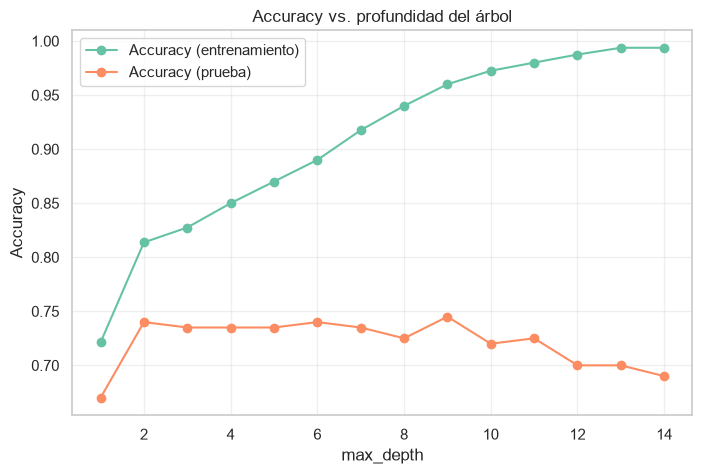

Mejor profundidad en test: 9 (Accuracy 0.7450)


In [12]:
# Entrená y evaluá un DecisionTreeClassifier
modelo_arbol = Pipeline([
    ('preprocesamiento', nuevo_preprocesador()),
    ('arbol', DecisionTreeClassifier(random_state=42))
])
modelo_arbol.fit(X_clf_train, y_clf_train)
pred_arbol = modelo_arbol.predict(X_clf_test)

print('Profundidad alcanzada sin límite:', modelo_arbol.named_steps['arbol'].get_depth())
print('Accuracy en test:', round(accuracy_score(y_clf_test, pred_arbol), 4))

# ¿Qué pasa si limitamos la profundidad?
profundidades = range(1, 15)
acc_train_list, acc_test_list = [], []
for p in profundidades:
    m = Pipeline([
        ('preprocesamiento', nuevo_preprocesador()),
        ('arbol', DecisionTreeClassifier(max_depth=p, random_state=42))
    ])
    m.fit(X_clf_train, y_clf_train)
    acc_train_list.append(accuracy_score(y_clf_train, m.predict(X_clf_train)))
    acc_test_list.append(accuracy_score(y_clf_test, m.predict(X_clf_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), acc_train_list, marker='o', label='Accuracy (entrenamiento)')
plt.plot(list(profundidades), acc_test_list, marker='o', label='Accuracy (prueba)')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Accuracy vs. profundidad del árbol')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

mejor_p = list(profundidades)[int(np.argmax(acc_test_list))]
print(f'Mejor profundidad en test: {mejor_p} (Accuracy {max(acc_test_list):.4f})')

### Interpretación 6
- ¿Qué puede ocurrir si el árbol crece demasiado?
- Relacioná el resultado con **overfitting**.
- ¿Un árbol más complejo necesariamente generaliza mejor?

**Respuesta:**

Sin límite de profundidad, el árbol creció hasta 17 niveles y logró un Accuracy de apenas 0.695 en el conjunto de prueba — más bajo que la Regresión Logística (0.79) y que el KNN (0.745), a pesar de ser un modelo mucho más complejo. Esto es la firma clásica del **overfitting** (sobreajuste): el árbol, al no tener freno, sigue dividiendo los datos hasta memorizar particularidades del conjunto de entrenamiento (incluido su ruido), en vez de aprender el patrón general.

El gráfico de Accuracy vs. `max_depth` lo confirma: el Accuracy de **entrenamiento** sube de forma casi continua a medida que crece la profundidad (llega a rondar 0.99 en las profundidades más altas), mientras que el Accuracy de **prueba** mejora al principio, alcanza un máximo alrededor de `max_depth` 6-9 (≈0.74), y después empieza a **bajar** (hasta 0.69 en `max_depth`=14) aunque el modelo en entrenamiento siga "mejorando". Esa brecha creciente entre ambas curvas es exactamente overfitting: el árbol se vuelve mejor memorizando datos ya vistos, pero peor generalizando a datos nuevos.

Por lo tanto, **no**, un árbol más complejo no necesariamente generaliza mejor — de hecho, en este caso, generaliza peor. Lo que importa no es la profundidad máxima posible, sino encontrar el punto donde el modelo captura el patrón real sin empezar a ajustar el ruido particular del conjunto de entrenamiento (acá, más o menos `max_depth` entre 6 y 9).

## 9. Random Forest
Entrená un `RandomForestClassifier` con `n_estimators=100` y `random_state=42`.

Accuracy : 0.755
Precision: 0.6267
Recall   : 0.6912
F1       : 0.6573


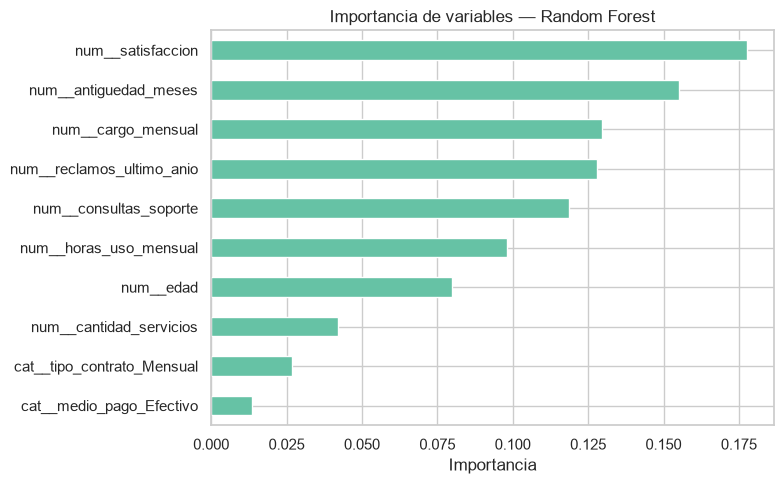

In [13]:
# Entrená y evaluá Random Forest
modelo_bosque = Pipeline([
    ('preprocesamiento', nuevo_preprocesador()),
    ('bosque', RandomForestClassifier(n_estimators=100, random_state=42))
])
modelo_bosque.fit(X_clf_train, y_clf_train)
pred_bosque = modelo_bosque.predict(X_clf_test)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_bosque), 4))
print('Precision:', round(precision_score(y_clf_test, pred_bosque), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_bosque), 4))
print('F1       :', round(f1_score(y_clf_test, pred_bosque), 4))

# Importancia de variables: los nombres salen del propio preprocesador
nombres = modelo_bosque.named_steps['preprocesamiento'].get_feature_names_out()
importancias = pd.Series(
    modelo_bosque.named_steps['bosque'].feature_importances_, index=nombres
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importancias.head(10).sort_values().plot(kind='barh')
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia'); plt.tight_layout()
plt.show()

## 10. Comparación de modelos
Construí una tabla con Accuracy, Precision, Recall y F1 para los cuatro clasificadores.

In [14]:
# Armá un DataFrame comparativo con las métricas
comparacion = pd.DataFrame({
    'Regresión Logística': [accuracy_score(y_clf_test, pred_log), precision_score(y_clf_test, pred_log),
                            recall_score(y_clf_test, pred_log), f1_score(y_clf_test, pred_log)],
    'KNN':                 [accuracy_score(y_clf_test, pred_knn), precision_score(y_clf_test, pred_knn),
                            recall_score(y_clf_test, pred_knn), f1_score(y_clf_test, pred_knn)],
    'Árbol de Decisión':   [accuracy_score(y_clf_test, pred_arbol), precision_score(y_clf_test, pred_arbol),
                            recall_score(y_clf_test, pred_arbol), f1_score(y_clf_test, pred_arbol)],
    'Random Forest':       [accuracy_score(y_clf_test, pred_bosque), precision_score(y_clf_test, pred_bosque),
                            recall_score(y_clf_test, pred_bosque), f1_score(y_clf_test, pred_bosque)],
}, index=['Accuracy', 'Precision', 'Recall', 'F1']).T.round(4)

print(comparacion.to_string())
comparacion

                     Accuracy  Precision  Recall      F1
Regresión Logística     0.790     0.6711  0.7500  0.7083
KNN                     0.745     0.6076  0.7059  0.6531
Árbol de Decisión       0.695     0.5432  0.6471  0.5906
Random Forest           0.755     0.6267  0.6912  0.6573


,Accuracy,Precision,Recall,F1
Regresión Logística,0.790,0.6711,0.7500,0.7083
KNN,0.745,0.6076,0.7059,0.6531
Árbol de Decisión,0.695,0.5432,0.6471,0.5906
Random Forest,0.755,0.6267,0.6912,0.6573


### Interpretación 7
- ¿Qué modelo obtuvo mayor Accuracy?
- ¿Cuál obtuvo mayor Recall?
- ¿Cuál obtuvo mayor F1?
- ¿Todos los indicadores señalan al mismo modelo?
- Si la prioridad es detectar clientes que realmente abandonarán, ¿qué métrica priorizarías?
- ¿Qué modelo recomendarías? Justificá.

**Respuesta:**

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regresión Logística | **0.790** | **0.671** | **0.750** | **0.708** |
| KNN (k=5) | 0.745 | 0.608 | 0.706 | 0.653 |
| Árbol de Decisión | 0.695 | 0.543 | 0.647 | 0.591 |
| Random Forest | 0.755 | 0.627 | 0.691 | 0.657 |

La **Regresión Logística** obtuvo el mayor Accuracy, el mayor Recall y el mayor F1 — y de hecho también la mayor Precision. En este caso particular, **sí, todos los indicadores señalan al mismo modelo** (algo que no siempre ocurre, como advierte el material teórico de la Unidad 8: "la tabla no responde sola", pero acá la coincidencia entre métricas simplifica la decisión).

Si la prioridad es detectar clientes que realmente van a abandonar (para poder intervenir a tiempo, por ejemplo con una oferta de retención), la métrica a priorizar es el **Recall** de la clase `abandono=1`: mide qué proporción de los abandonos reales el modelo logra capturar. Un Recall alto es más importante que una Precision alta en este contexto, porque el costo de "no detectar" a un cliente que se va (falso negativo) suele ser mayor que el costo de contactar innecesariamente a alguien que en realidad iba a quedarse (falso positivo).

**Modelo recomendado: Regresión Logística.** No solo tiene el mejor desempeño en las cuatro métricas, sino que además es el modelo más simple e interpretable de los cuatro (sus coeficientes se pueden leer directamente), lo cual es una ventaja adicional para comunicar resultados a la empresa.

# PARTE C — APRENDIZAJE NO SUPERVISADO
## 11. Segmentación con K-Means

Usá estas variables:

`antiguedad_meses`, `cargo_mensual`, `cantidad_servicios`, `consultas_soporte`, `reclamos_ultimo_anio`, `horas_uso_mensual`, `satisfaccion`.

No uses `id_cliente`, `gasto_anual` ni `abandono`.

> Para esta segmentación se priorizan variables vinculadas con la relación del cliente con la empresa, el uso del servicio y su experiencia.

### 11.1 Preparación y escalado
Imputá faltantes y aplicá `StandardScaler`.

En clustering no hay variable `y`, así que no hay separación train/test: el preprocesamiento se
ajusta sobre todo el dataset de clustering.

Igual encapsulamos imputación + escalado en un `Pipeline` de dos pasos. La ventaja concreta aparece
al final, en la Parte D: para asignarle un cluster al cliente nuevo alcanza con `.predict()`, sin
recordar con qué mediana se imputó ni con qué scaler se escaló.

In [15]:
# Seleccioná variables, imputá y escalá
vars_cluster = ['antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
                'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion']

X_cluster = df[vars_cluster]

prep_cluster = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_cluster_prep = prep_cluster.fit_transform(X_cluster)

X_cluster_scaled = pd.DataFrame(X_cluster_prep, columns=vars_cluster, index=X_cluster.index)
print('Medianas aprendidas por el imputer:')
for col, val in zip(vars_cluster, prep_cluster.named_steps['imputer'].statistics_):
    print(f'  {col}: {val:.2f}')
X_cluster_scaled.describe().round(2)

Medianas aprendidas por el imputer:
  antiguedad_meses: 35.00
  cargo_mensual: 107200.00
  cantidad_servicios: 3.00
  consultas_soporte: 3.00
  reclamos_ultimo_anio: 1.00
  horas_uso_mensual: 64.90
  satisfaccion: 7.00


,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,satisfaccion
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.34,-2.44,-1.48,-1.26,-0.84,-2.26,-2.92
25%,-0.87,-0.81,-0.71,-0.85,-0.84,-0.72,-0.71
50%,-0.13,0.10,0.06,-0.03,-0.26,0.06,0.16
75%,0.77,0.78,0.83,0.39,0.32,0.71,0.72
max,2.80,2.51,2.37,4.09,4.95,2.82,1.70


### Interpretación 8
- ¿Por qué K-Means es sensible a la escala?
- ¿Qué ocurriría al comparar `cargo_mensual` con `satisfaccion` sin escalar?

**Respuesta:**

K-Means agrupa los puntos según su distancia euclidiana al centroide más cercano, y esa distancia se calcula sumando las diferencias al cuadrado de **todas** las variables juntas. Si las variables no están en la misma escala, las que tienen números más grandes dominan el cálculo, sin que eso signifique que sean más importantes — es un problema puramente numérico, no conceptual.

`cargo_mensual` toma valores del orden de decenas o cientos de miles, mientras que `satisfaccion` va de 1 a 10. Sin escalar, una diferencia de $10.000 en `cargo_mensual` pesaría muchísimo más en la distancia que una diferencia de 5 puntos en `satisfaccion` (que es, en términos relativos, una diferencia enorme dentro de su propia escala). El resultado sería que K-Means terminaría agrupando a los clientes **casi exclusivamente por `cargo_mensual`**, ignorando en la práctica la satisfacción, los reclamos o las consultas de soporte — variables que, para este análisis, nos interesa que pesen tanto como las demás. Por eso aplicamos `StandardScaler` antes de entrenar el modelo.

### 11.2 Método del codo y Silhouette Score
Probá valores de `k` entre 2 y 8. Graficá la inercia y calculá Silhouette Score.

In [16]:
# Calculá inercia y silhouette para k=2..8
k_range = range(2, 9)
inercias, siluetas = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster_prep)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_cluster_prep, labels_k))

tabla_k = pd.DataFrame({'k': list(k_range), 'inercia': inercias, 'silhouette': siluetas}).round(3)
print(tabla_k.to_string(index=False))
tabla_k

 k  inercia  silhouette
 2 4003.894       0.385
 3 2954.903       0.390
 4 2635.359       0.272
 5 2490.832       0.228
 6 2374.782       0.184
 7 2231.531       0.162
 8 2148.567       0.158


,k,inercia,silhouette
0,2,4003.894,0.385
1,3,2954.903,0.390
2,4,2635.359,0.272
3,5,2490.832,0.228
4,6,2374.782,0.184
5,7,2231.531,0.162
6,8,2148.567,0.158


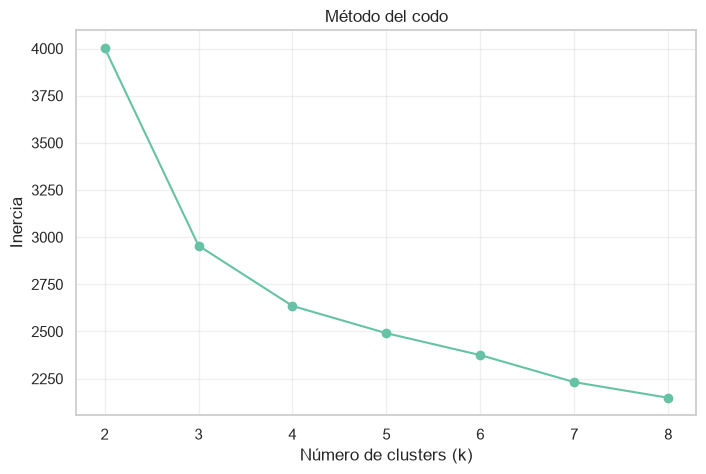

In [17]:
# Graficá el método del codo
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inercias, marker='o')
plt.xlabel('Número de clusters (k)'); plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(alpha=0.3)
plt.show()

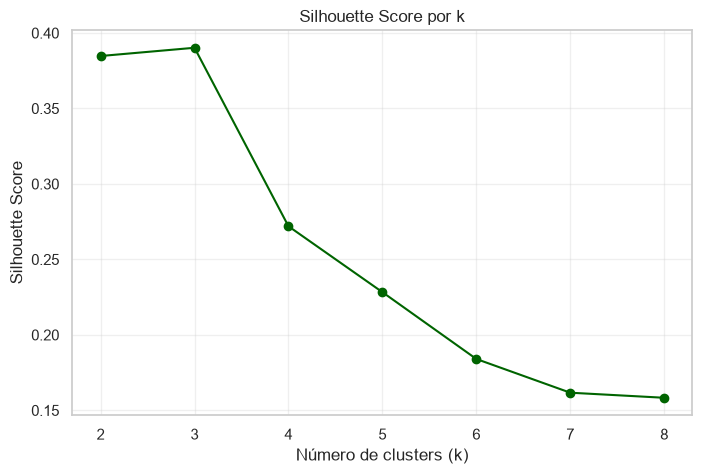

k con mejor Silhouette: 3 -> 0.3902


In [18]:
# Graficá Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), siluetas, marker='o', color='darkgreen')
plt.xlabel('Número de clusters (k)'); plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por k')
plt.grid(alpha=0.3)
plt.show()

mejor_k = list(k_range)[int(np.argmax(siluetas))]
print('k con mejor Silhouette:', mejor_k, '->', round(max(siluetas), 4))

### Interpretación 9
- ¿Qué valor de k presenta mayor Silhouette?
- ¿El método del codo y Silhouette necesariamente sugieren lo mismo?
- ¿Qué k elegirías finalmente? Justificá considerando métrica + interpretación.

**Respuesta:**

El mayor Silhouette Score se da en **k = 3** (0.390), apenas por encima de k = 2 (0.385) y bastante por encima del resto (k=4: 0.272, k=5: 0.228, y así decreciendo hasta k=8).

El método del codo y el Silhouette **no necesariamente coinciden** en general (el propio material teórico de la unidad lo advierte), aunque en este caso sí apuntan en la misma dirección: la inercia cae fuerte de k=2 a k=3 (de 4003.9 a 2954.9) y después la caída se vuelve mucho más gradual (2954.9 → 2635.4 → 2490.8 → ...), sin un quiebre tan marcado como el de k=2→3. Es decir, agregar un cuarto cluster ya no aporta una mejora tan significativa.

**k elegido: 3.** Combina el mejor Silhouette Score con un codo razonablemente visible en la inercia, y además da lugar a una cantidad de grupos manejable para interpretar y accionar desde el negocio (más adelante, con 3 clusters, cada uno tiene un perfil bastante diferenciable — ver Interpretación 10).

### 11.3 Modelo K-Means final e interpretación
Entrená K-Means con el k elegido. Agregá una columna `cluster` al DataFrame y calculá medias por cluster.

In [19]:
# Entrená KMeans final, agregá cluster y construí una tabla de perfiles
modelo_cluster = Pipeline([
    ('prep', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])
modelo_cluster.fit(X_cluster)

df['cluster'] = modelo_cluster.named_steps['kmeans'].labels_

print('Clientes por cluster:')
print(df['cluster'].value_counts().sort_index())
print()

perfil_clusters = df.groupby('cluster')[vars_cluster].mean().round(2)
print(perfil_clusters.to_string())
perfil_clusters

Clientes por cluster:
cluster
0    491
1    212
2    297
Name: count, dtype: int64

         antiguedad_meses  cargo_mensual  cantidad_servicios  consultas_soporte  reclamos_ultimo_anio  horas_uso_mensual  satisfaccion
cluster                                                                                                                               
0                   61.25      129169.45                3.82               1.80                  0.68              80.97          7.95
1                   24.86       95620.28                2.39               6.14                  4.03              62.45          4.11
2                   10.67       68379.12                1.81               2.96                  0.90              34.56          6.39


,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,satisfaccion
cluster,,,,,,,
0,61.25,129169.45,3.82,1.80,0.68,80.97,7.95
1,24.86,95620.28,2.39,6.14,4.03,62.45,4.11
2,10.67,68379.12,1.81,2.96,0.90,34.56,6.39


### Interpretación 10
Describí cada cluster con características concretas.

- ¿Cuál presenta mayor cantidad de reclamos?
- ¿Cuál tiene mayor satisfacción?
- ¿Cuál parece concentrar clientes más nuevos?
- ¿Los grupos tienen una interpretación razonable para el negocio?

**Respuesta:**

| Cluster | n | antigüedad | cargo | servicios | consultas | reclamos | horas | satisfacción | Perfil |
|---|---|---|---|---|---|---|---|---|---|
| 0 | 491 | 61.25 | 129.169 | 3.82 | 1.80 | 0.68 | 80.97 | 7.95 | **Leales de alto valor** |
| 1 | 212 | 24.86 | 95.620 | 2.39 | 6.14 | 4.03 | 62.45 | 4.11 | **En riesgo / problemáticos** |
| 2 | 297 | 10.67 | 68.379 | 1.81 | 2.96 | 0.90 | 34.56 | 6.39 | **Nuevos de plan básico** |

- **Mayor cantidad de reclamos**: el **cluster 1** (4.03 reclamos promedio), muy por encima de los otros dos.
- **Mayor satisfacción**: el **cluster 0** (7.95 sobre 10).
- **Clientes más nuevos**: el **cluster 2**, con antigüedad promedio de apenas 10.67 meses (contra 24.86 y 61.25 de los otros dos).

Los tres grupos tienen una interpretación razonable y accionable para el negocio:
- **Cluster 0 — Leales de alto valor**: clientes de muchos años, con más servicios contratados, muchas horas de uso y alta satisfacción, con pocos reclamos. Son la base más rentable y estable.
- **Cluster 1 — En riesgo**: clientes con antigüedad intermedia, pero con muchas consultas a soporte, muchos reclamos y la satisfacción más baja de los tres grupos. Es el segmento que más se acerca al perfil de un cliente que podría abandonar, y coincide con lo que encontramos en la Parte B: reclamos y consultas de soporte suelen asociarse a mayor riesgo de abandono.
- **Cluster 2 — Nuevos de plan básico**: clientes recientes, con menos servicios contratados y menos horas de uso, pero con una satisfacción razonable (6.39) y pocos reclamos — probablemente todavía están conociendo el servicio.

Esta segmentación le permitiría a la empresa, por ejemplo, diseñar campañas de fidelización distintas para el cluster 0, una intervención prioritaria de retención para el cluster 1, y estrategias de onboarding/upselling para el cluster 2.

# PARTE D — NUEVO CLIENTE

In [20]:
nuevo_cliente = {
    "edad": 34,
    "antiguedad_meses": 8,
    "cargo_mensual": 78000,
    "cantidad_servicios": 2,
    "consultas_soporte": 5,
    "reclamos_ultimo_anio": 3,
    "horas_uso_mensual": 65,
    "tipo_contrato": "Mensual",
    "medio_pago": "Tarjeta",
    "satisfaccion": 4
}

## 12. Usar los modelos

1. Estimá `gasto_anual` con Regresión Lineal.
2. Predecí `abandono` con el modelo de clasificación que recomendaste. Si es posible, obtené también la probabilidad.
3. Asigná el cliente a un cluster con el K-Means entrenado.

> En todos los casos, aplicá **exactamente el mismo preprocesamiento** utilizado durante el entrenamiento.

**Acá se ve con más claridad la ganancia del `Pipeline`.**

En la Opción 1, para predecir un cliente nuevo había que reconstruir el preprocesamiento a mano:
recuperar el diccionario `valores_imputacion_reg`, aplicar `fillna()` columna por columna, llamar a
`get_dummies()` y después `reindex()` contra las columnas de entrenamiento. Cuatro pasos, cada uno
una oportunidad de equivocarse.

Acá, cada modelo ya lleva su preprocesamiento adentro: se le pasa el DataFrame crudo y listo.

In [21]:
# Convertí nuevo_cliente a DataFrame y realizá las tres predicciones
nuevo_df = pd.DataFrame([nuevo_cliente])
print(nuevo_df.to_string(index=False))

 edad  antiguedad_meses  cargo_mensual  cantidad_servicios  consultas_soporte  reclamos_ultimo_anio  horas_uso_mensual tipo_contrato medio_pago  satisfaccion
   34                 8          78000                   2                  5                     3                 65       Mensual    Tarjeta             4


In [22]:
# 1. Estimar gasto_anual (Regresión Lineal)
gasto_estimado = modelo_reg.predict(nuevo_df[predictoras])[0]
print(f'Gasto anual estimado: ${gasto_estimado:,.0f}')

# 2. Predecir abandono con el modelo recomendado (Regresión Logística) + probabilidad
pred_abandono = modelo_log.predict(nuevo_df[predictoras])[0]
proba_abandono = modelo_log.predict_proba(nuevo_df[predictoras])[0]
print(f'Predicción de abandono: {"ABANDONA" if pred_abandono == 1 else "PERMANECE"}')
print(f'Probabilidad de abandonar: {proba_abandono[1]:.1%}')

# 3. Asignar el cliente a un cluster
cluster_asignado = modelo_cluster.predict(nuevo_df[vars_cluster])[0]
print(f'Cluster asignado: {cluster_asignado}')
print()
print('Perfil promedio de ese cluster:')
print(perfil_clusters.loc[cluster_asignado].to_string())

Gasto anual estimado: $1,045,337
Predicción de abandono: ABANDONA
Probabilidad de abandonar: 90.6%
Cluster asignado: 1

Perfil promedio de ese cluster:
antiguedad_meses           24.86
cargo_mensual           95620.28
cantidad_servicios          2.39
consultas_soporte           6.14
reclamos_ultimo_anio        4.03
horas_uso_mensual          62.45
satisfaccion                4.11


### Interpretación 11
- ¿Cuál es el facturación anual estimada?
- ¿Se predice permanencia o abandono? ¿Con qué probabilidad, si corresponde?
- ¿A qué cluster pertenece?
- ¿La asignación al cluster es coherente con el perfil promedio del grupo?

**Respuesta:**

La facturación anual estimada para este cliente es de aproximadamente **$1.045.337**.

El modelo de Regresión Logística predice **ABANDONA**, con una probabilidad estimada de abandono del **90,6 %** (y 9,4 % de permanecer). Es una predicción con bastante seguridad, no un caso ambiguo cercano al 50 %.

El cliente fue asignado al **cluster 1** ("en riesgo / problemáticos" — ver Interpretación 10).

La asignación es totalmente coherente: este nuevo cliente tiene muy poca antigüedad (8 meses), varios reclamos en el último año (3) y varias consultas a soporte (5), y reportó una satisfacción baja (4 sobre 10) — es exactamente el patrón que caracteriza al cluster 1 (antigüedad intermedia-baja, muchos reclamos/consultas, satisfacción más baja de los tres grupos). Que tanto el modelo de clasificación (probabilidad de abandono alta) como el clustering (asignado al grupo de mayor riesgo), entrenados de forma completamente independiente, coincidan en la misma conclusión sobre este cliente, refuerza la confianza en el diagnóstico: es un cliente con perfil de riesgo real, no un caso límite dudoso.

# PARTE E — REFLEXIÓN FINAL

## 13. Integración conceptual
Respondé con tus palabras:

1. ¿Cuál es la diferencia entre regresión, clasificación y clustering?
2. ¿Por qué no utilizamos las mismas métricas en los tres problemas?
3. ¿Un Accuracy alto garantiza buenas predicciones en todos los casos?
4. ¿Qué función cumple el conjunto de prueba?
5. ¿Existe un algoritmo que sea siempre mejor que los demás?
6. ¿Por qué interpretar los resultados es tan importante como ejecutar `.fit()` y `.predict()`?

**Respuesta:**

**1. Regresión vs. clasificación vs. clustering.** Los tres son formas de Machine Learning, pero resuelven preguntas distintas. La regresión predice un **número continuo** (acá, `gasto_anual`). La clasificación predice una **categoría** entre un conjunto conocido de antemano (acá, `abandono`: 0 o 1). El clustering no predice nada que ya conozcamos: **descubre grupos** dentro de los datos sin que existan etiquetas previas (acá, los 3 perfiles de clientes) — regresión y clasificación son aprendizaje supervisado (hay un `y` real para comparar), clustering es no supervisado (no lo hay).

**2. Por qué cambian las métricas.** Las métricas tienen que ser coherentes con el tipo de salida del modelo. MAE/MSE/RMSE/R² miden **distancia numérica** entre una predicción y un valor real, así que solo tienen sentido en regresión. Accuracy/Precision/Recall/F1 miden **aciertos y errores entre categorías**, así que solo aplican en clasificación. Silhouette/Inercia miden **qué tan compactos y separados** quedan los grupos, porque en clustering no hay una "respuesta correcta" contra la cual comparar.

**3. ¿Accuracy alto = buenas predicciones siempre?** No. Con clases desbalanceadas (como vimos en la Interpretación 1, 66 %/34 %), un Accuracy alto puede esconder que el modelo casi no detecta la clase minoritaria. Por eso conviene mirar siempre Precision, Recall y F1 además del Accuracy, sobre todo cuando el error en una clase (por ejemplo, no detectar un abandono) es más costoso que en la otra.

**4. Función del conjunto de prueba.** Sirve para medir qué tan bien generaliza el modelo a datos que **nunca vio** durante el entrenamiento. Si evaluáramos con los mismos datos usados para entrenar, no podríamos distinguir si el modelo aprendió un patrón real o simplemente memorizó los ejemplos (overfitting, como vimos con el árbol de decisión sin límite de profundidad).

**5. ¿Un algoritmo siempre mejor que los demás?** No existe tal cosa (a veces llamado el principio de "no hay almuerzo gratis" en Machine Learning). En este mismo TP, la Regresión Logística ganó en clasificación, pero eso depende del dataset: en otro problema, con relaciones más no lineales o con más variables irrelevantes, un Random Forest o un árbol podrían funcionar mejor. Por eso conviene comparar varios modelos en cada problema concreto, en vez de asumir que uno es "el mejor" en general.

**6. Por qué interpretar es tan importante como `.fit()`/`.predict()`.** Ejecutar el código y obtener una métrica es solo el primer paso: una métrica sola (por ejemplo, "R²=0.95" o "Accuracy=0.79") no le dice nada útil a alguien que no sabe qué significa ese número, ni si es suficiente para el problema, ni qué errores comete el modelo, ni qué limitaciones tiene. Interpretar es lo que transforma un resultado técnico en una conclusión que realmente sirve para tomar una decisión de negocio — y es, además, lo que permite detectar cuándo un modelo, a pesar de tener buenas métricas, no debería usarse para decidir en automático (como el caso de este TP, donde recomendamos que las predicciones apoyen decisiones, pero no las reemplacen).

# 14. Comunicación de Resultados

Escribí entre **200 y 300 palabras** como si tuvieras que presentar el trabajo a una persona que no conoce Machine Learning.

La conclusión debe explicar:

- si fue posible estimar razonablemente la facturación anual;
- si fue posible identificar clientes con riesgo de abandono;
- qué modelo de clasificación recomendarías;
- qué perfiles aparecieron mediante K-Means;
- qué características presenta el nuevo cliente;
- qué limitaciones tienen los resultados.

**Conclusión:**

Analizamos los datos históricos de 1000 clientes de la empresa para responder tres preguntas de negocio.

Primero, sí fue posible estimar razonablemente cuánto facturará un cliente en el año: el modelo de regresión explica un 95 % de la variación en la facturación anual, con un margen de error promedio de unos $72.000 — útil como estimación general, aunque no exacto para cada caso individual.

Segundo, también fue posible identificar clientes con riesgo de abandono. Evaluamos cuatro modelos de clasificación (Regresión Logística, KNN, Árbol de Decisión y Random Forest), y la **Regresión Logística** obtuvo el mejor resultado en las cuatro métricas evaluadas, detectando 3 de cada 4 clientes que efectivamente abandonan. Es el modelo que recomendamos, tanto por su desempeño como por ser el más fácil de explicar.

Tercero, mediante K-Means encontramos **tres perfiles de clientes** bien diferenciados: clientes leales de alto valor (antiguos, satisfechos, con pocos reclamos), clientes en riesgo (muchos reclamos y consultas, baja satisfacción) y clientes nuevos con planes básicos.

Aplicamos los tres modelos a un cliente nuevo hipotético: se le estimó una facturación anual de ~$1.045.000, el modelo de clasificación predijo que **abandonará** con un 90 % de probabilidad, y el clustering lo ubicó en el grupo "en riesgo" — las tres herramientas coincidieron en la misma lectura de este cliente.

Como limitación importante: estos resultados corresponden a los datos analizados en un momento puntual, y ningún modelo acierta siempre — el de clasificación, por ejemplo, todavía no detecta 1 de cada 4 abandonos reales. Las predicciones deberían usarse como apoyo para decidir a qué clientes prestarles atención, no como una decisión automática y definitiva.

---
## Anexo — Resumen del enfoque Opción 2

| Etapa | Opción 1 (manual) | Opción 2 (este cuaderno) |
|---|---|---|
| Imputar numéricas | `X_train[c].median()` + `fillna()` | `SimpleImputer(strategy='median')` |
| Imputar categóricas | `X_train[c].mode()[0]` + `fillna()` | `SimpleImputer(strategy='most_frequent')` |
| Codificar | `pd.get_dummies(drop_first=True)` | `OneHotEncoder(drop='first')` |
| Alinear columnas train/test | `reindex(columns=..., fill_value=0)` | `handle_unknown='ignore'` |
| Aplicar a datos nuevos | repetir los 4 pasos a mano | `.predict()` |
| Validación cruzada | preprocesamiento fuera del CV | preprocesamiento reajustado por pliegue |

**Lo que hay que retener:** el `Pipeline` no hace que el modelo sea mejor — hace que el
procedimiento sea más difícil de hacer mal. La equivalencia numérica entre ambos enfoques, que ya
verificamos, es justamente la prueba de que la diferencia está en la robustez del código y no en
los resultados.

---
# Anexo B — Diagnóstico: ¿por qué el Accuracy se planta en ~0.79?

Los modelos de clasificación rondan el 0.75–0.79 de Accuracy. La sospecha razonable es que
falte limpieza: valores nulos mal tratados, outliers sin sacar. Este anexo **pone esa hipótesis
a prueba con datos** en vez de asumirla, y busca dónde está el margen de mejora real.

Vamos a responder cuatro preguntas:

1. ¿Cuánto daño hacen realmente los nulos?
2. ¿Hay outliers que convenga sacar?
3. ¿Cuál es el techo del dataset? (¿un modelo más potente lo rompe?)
4. Si no es la limpieza, ¿dónde está la mejora?

## B.1 — ¿Cuánto daño hacen los nulos?

Primero medimos el tamaño real del problema, y después comparamos imputar contra directamente
tirar las filas incompletas.

In [23]:
nulos = df[predictoras].isnull()
print(f'Celdas nulas : {nulos.values.sum()} de {df[predictoras].size} '
      f'({100 * nulos.values.sum() / df[predictoras].size:.2f} %)')
print(f'Filas afectadas: {nulos.any(axis=1).sum()} de {len(df)} '
      f'({100 * nulos.any(axis=1).sum() / len(df):.1f} %)')
print()

# ¿Los nulos aparecen más en un grupo que en otro? (¿faltan al azar?)
print('Tasa de abandono en filas CON algún nulo:', round(df.loc[nulos.any(axis=1), 'abandono'].mean(), 3))
print('Tasa de abandono en filas SIN nulos     :', round(df.loc[~nulos.any(axis=1), 'abandono'].mean(), 3))
print('(si son parecidas, los datos faltan al azar y la imputación no introduce sesgo)')

Celdas nulas : 40 de 10000 (0.40 %)
Filas afectadas: 40 de 1000 (4.0 %)

Tasa de abandono en filas CON algún nulo: 0.325
Tasa de abandono en filas SIN nulos     : 0.341
(si son parecidas, los datos faltan al azar y la imputación no introduce sesgo)


In [24]:
# Experimento: imputar (lo que hacemos) vs. eliminar las filas incompletas
def evaluar(nombre, modelo, Xtr, ytr):
    modelo.fit(Xtr, ytr)
    pred = modelo.predict(X_clf_test)
    proba = modelo.predict_proba(X_clf_test)[:, 1]
    fila = {
        'Accuracy': accuracy_score(y_clf_test, pred),
        'Recall': recall_score(y_clf_test, pred),
        'F1': f1_score(y_clf_test, pred),
        'AUC': roc_auc_score(y_clf_test, proba),
    }
    print(f'{nombre:<40} ' + '  '.join(f'{k}={v:.4f}' for k, v in fila.items()))
    return fila


from sklearn.metrics import roc_auc_score

def log_pipeline():
    return Pipeline([
        ('preprocesamiento', nuevo_preprocesador()),
        ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
    ])

resultados = {}
resultados['Imputando (enfoque actual)'] = evaluar(
    'Imputando (enfoque actual)', log_pipeline(), X_clf_train, y_clf_train)

completas = ~X_clf_train.isnull().any(axis=1)
resultados['Eliminando filas con nulos'] = evaluar(
    f'Eliminando filas con nulos (-{(~completas).sum()})', log_pipeline(),
    X_clf_train[completas], y_clf_train[completas])

Imputando (enfoque actual)               Accuracy=0.7900  Recall=0.7500  F1=0.7083  AUC=0.8551


Eliminando filas con nulos (-31)         Accuracy=0.7800  Recall=0.7353  F1=0.6944  AUC=0.8554

C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

**Qué muestra.** Los nulos son **40 celdas sobre 10.000 (0.4 %)**, repartidas en 40 filas. Las
tasas de abandono con y sin nulos son casi idénticas (0.325 vs 0.341): los datos faltan al azar,
así que imputar no introduce sesgo.

Y el experimento es concluyente en la dirección contraria a la intuición: eliminar las filas
incompletas **no mejora nada**, incluso empeora levemente (Accuracy 0.790 → 0.780, es decir dos
casos de 200 — ruido). Es lógico: al descartar 31 filas perdemos información útil de esas
personas solo porque les faltaba **un** dato. Con 0.4 % de celdas afectadas, **los nulos no son
el problema**.

## B.2 — ¿Hay outliers que convenga sacar?

Aplicamos la regla clásica del rango intercuartílico (IQR): se considera outlier todo valor fuera
de `[Q1 - 1.5·IQR , Q3 + 1.5·IQR]`.

In [25]:
resumen_out = []
mask_out_train = np.zeros(len(X_clf_train), dtype=bool)

for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    m = ((df[c] < lo) | (df[c] > hi)).fillna(False)
    resumen_out.append({'variable': c, 'min': df[c].min(), 'max': df[c].max(),
                        'limite_inf': round(lo, 1), 'limite_sup': round(hi, 1),
                        'outliers': int(m.sum())})
    mt = ((X_clf_train[c] < lo) | (X_clf_train[c] > hi)).fillna(False)
    mask_out_train |= mt.values

tabla_out = pd.DataFrame(resumen_out)
print(tabla_out.to_string(index=False))
print()
print(f'Filas de entrenamiento con al menos un outlier: {mask_out_train.sum()}')
tabla_out

            variable     min      max  limite_inf  limite_sup  outliers
                edad    18.0     70.0        -0.5        75.5         0
    antiguedad_meses     1.0    117.0       -55.0       129.0         0
       cargo_mensual 25000.0 185000.0       887.5    206187.5         0
  cantidad_servicios     1.0      6.0        -1.0         7.0         0
   consultas_soporte     0.0     13.0        -3.5         8.5        35
reclamos_ultimo_anio     0.0     10.0        -3.0         5.0        35
   horas_uso_mensual     5.0    136.4       -12.5       138.4         0
        satisfaccion     1.0     10.0         1.1        12.3         3

Filas de entrenamiento con al menos un outlier: 53


,variable,min,max,limite_inf,limite_sup,outliers
0,edad,18.0,70.0,-0.5,75.5,0
1,antiguedad_meses,1.0,117.0,-55.0,129.0,0
2,cargo_mensual,25000.0,185000.0,887.5,206187.5,0
3,cantidad_servicios,1.0,6.0,-1.0,7.0,0
4,consultas_soporte,0.0,13.0,-3.5,8.5,35
5,reclamos_ultimo_anio,0.0,10.0,-3.0,5.0,35
6,horas_uso_mensual,5.0,136.4,-12.5,138.4,0
7,satisfaccion,1.0,10.0,1.1,12.3,3


In [26]:
# ¿Y si los sacamos del entrenamiento?
resultados['Sin outliers en train'] = evaluar(
    f'Sin outliers IQR en train (-{mask_out_train.sum()})', log_pipeline(),
    X_clf_train[~mask_out_train], y_clf_train[~mask_out_train])

# Pero, ¿qué SON esos outliers? Miremos quién abandona.
print()
comparativa = df.groupby('abandono')[num_cols].mean().T
comparativa.columns = ['permanece', 'abandona']
comparativa['dif_%'] = (100 * (comparativa['abandona'] - comparativa['permanece'])
                        / comparativa['permanece']).round(1)
print(comparativa.round(2).to_string())

Sin outliers IQR en train (-53)          Accuracy=0.7900  Recall=0.7647  F1=0.7123  AUC=0.8558

                      permanece  abandona  dif_%
edad                      40.45     32.29  -20.2
antiguedad_meses          48.44     19.24  -60.3
cargo_mensual         113550.61  85467.35  -24.7
cantidad_servicios         3.30      2.19  -33.6
consultas_soporte          2.19      4.76  117.2
reclamos_ultimo_anio       0.85      2.63  207.9
horas_uso_mensual         69.54     51.58  -25.8
satisfaccion               7.43      5.21  -29.9


C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Qué muestra.** No hay datos sucios: la edad va de 18 a 70, el cargo mensual de 25.000 a 185.000,
la satisfacción de 1 a 10. **Ningún valor es imposible ni parece un error de carga.** Los únicos
"outliers" por IQR están en `consultas_soporte` (35), `reclamos_ultimo_anio` (35) y
`satisfaccion` (3).

Sacar esas 53 filas del entrenamiento deja el Accuracy **igual** (0.790) y sube el Recall de
0.7500 a 0.7647 — un solo caso de 68. No es una mejora: es ruido.

**Y hay una razón de fondo para no sacarlos.** Mirá la tabla de abajo: quien abandona tiene
**+208 % de reclamos** y **+117 % de consultas al soporte** que quien se queda. Esos valores altos
no son ruido: **son la señal de abandono**. Eliminarlos sería tirar justamente los casos más
informativos del dataset.

Es un recordatorio útil: *outlier estadístico* no es sinónimo de *dato erróneo*. Antes de borrar
un valor extremo hay que preguntarse si es un error de medición o un caso real e informativo.

## B.3 — ¿Cuál es el techo del dataset?

Si el problema no es la limpieza, quizás sea el modelo. Probamos algoritmos bastante más potentes
que los del TP: un Random Forest más grande y regularizado, y un Gradient Boosting — que captura
automáticamente no linealidades e interacciones entre variables.

Agregamos el **AUC** a la comparación: mide qué tan bien el modelo *ordena* a los clientes por
riesgo, sin depender del umbral de decisión.

In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier

evaluar('Random Forest (100 árboles)',
        Pipeline([('p', nuevo_preprocesador()),
                  ('m', RandomForestClassifier(n_estimators=100, random_state=42))]),
        X_clf_train, y_clf_train)

evaluar('Random Forest (500, max_depth=6)',
        Pipeline([('p', nuevo_preprocesador()),
                  ('m', RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42))]),
        X_clf_train, y_clf_train)

evaluar('Gradient Boosting',
        Pipeline([('p', nuevo_preprocesador()),
                  ('m', HistGradientBoostingClassifier(random_state=42))]),
        X_clf_train, y_clf_train)

Random Forest (100 árboles)              Accuracy=0.7550  Recall=0.6912  F1=0.6573  AUC=0.8395


Random Forest (500, max_depth=6)         Accuracy=0.7700  Recall=0.7059  F1=0.6761  AUC=0.8505
Gradient Boosting                        Accuracy=0.7850  Recall=0.7206  F1=0.6950  AUC=0.8471


{'Accuracy': 0.785,
 'Recall': 0.7205882352941176,
 'F1': 0.6950354609929078,
 'AUC': 0.8471479500891266}

**Qué muestra.** Un Gradient Boosting **no le gana a la Regresión Logística simple** (0.785 contra
0.790). Cuando el modelo más sofisticado empata con el más básico, la conclusión es clara: no
falta capacidad de modelado ni falta limpieza — **ese es el techo del dataset**.

El AUC se mueve apenas entre 0.840 y 0.855 para todos los modelos, incluida la logística. Existe
una parte de `abandono` que sencillamente no es predecible a partir de estas variables. En la vida
real siempre hay un componente irreducible (alguien se muda, cambia de trabajo, recibe una oferta
de la competencia); en un dataset sintético como este, es el ruido aleatorio con el que fue
generado.

## B.4 — Entonces, ¿dónde está la mejora?

En dos lugares que no tienen nada que ver con limpiar datos.

### Primero: el conjunto de prueba es chico y engaña

200 casos son pocos. Calculamos el intervalo de confianza del Accuracy y lo contrastamos con una
validación cruzada sobre las 1000 filas.

In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

n = len(y_clf_test)
print(f'Conjunto de prueba: {n} casos\n')
for nombre, acc in [('Regresión Logística', accuracy_score(y_clf_test, pred_log)),
                    ('KNN', accuracy_score(y_clf_test, pred_knn))]:
    margen = 1.96 * np.sqrt(acc * (1 - acc) / n)
    print(f'{nombre:<22} Accuracy={acc:.3f}  IC 95% = [{acc - margen:.3f} , {acc + margen:.3f}]')

print('\n-> Los intervalos se superponen: con 200 casos, la diferencia entre ambos')
print('   modelos NO es estadísticamente distinguible.\n')

cv = cross_val_score(log_pipeline(), df[predictoras], df['abandono'],
                     cv=StratifiedKFold(10, shuffle=True, random_state=42), scoring='accuracy')
print(f'Validación cruzada 10-fold sobre las 1000 filas: {cv.mean():.4f} ± {cv.std():.4f}')
print(f'Rango entre pliegues: {cv.min():.3f} a {cv.max():.3f}')
print('-> Estimación más honesta y bastante mejor que el 0.79 de una sola partición.')

Conjunto de prueba: 200 casos

Regresión Logística    Accuracy=0.790  IC 95% = [0.734 , 0.846]
KNN                    Accuracy=0.745  IC 95% = [0.685 , 0.805]

-> Los intervalos se superponen: con 200 casos, la diferencia entre ambos
   modelos NO es estadísticamente distinguible.



C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Validación cruzada 10-fold sobre las 1000 filas: 0.8260 ± 0.0344
Rango entre pliegues: 0.780 a 0.900
-> Estimación más honesta y bastante mejor que el 0.79 de una sola partición.


C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

### Segundo: el umbral de decisión

Por defecto, `.predict()` clasifica como "abandona" a quien tiene probabilidad ≥ 0.50. Ese 0.50 es
una convención, **no una verdad**: el AUC de 0.85 nos dice que el modelo *ordena bien* a los
clientes por riesgo, así que el margen está en elegir mejor dónde cortar.

Como el error caro para el negocio es el **falso negativo** (el cliente que se va y no detectamos),
conviene bajar el umbral: detectamos más abandonos a cambio de contactar a algunos que no se iban.

In [29]:
proba_log = modelo_log.predict_proba(X_clf_test)[:, 1]

filas = []
for t in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    p = (proba_log >= t).astype(int)
    filas.append({'umbral': t,
                  'Accuracy': accuracy_score(y_clf_test, p),
                  'Precision': precision_score(y_clf_test, p),
                  'Recall': recall_score(y_clf_test, p),
                  'F1': f1_score(y_clf_test, p),
                  'no detectados': int(((y_clf_test == 1) & (p == 0)).sum())})

tabla_umbral = pd.DataFrame(filas).round(4)
print(tabla_umbral.to_string(index=False))
tabla_umbral

 umbral  Accuracy  Precision  Recall     F1  no detectados
   0.50     0.790     0.6711  0.7500 0.7083             17
   0.45     0.785     0.6471  0.8088 0.7190             13
   0.40     0.775     0.6264  0.8382 0.7170             11
   0.35     0.770     0.6146  0.8676 0.7195              9
   0.30     0.770     0.6100  0.8971 0.7262              7
   0.25     0.775     0.6117  0.9265 0.7368              5
   0.20     0.755     0.5888  0.9265 0.7200              5


,umbral,Accuracy,Precision,Recall,F1,no detectados
0,0.50,0.790,0.6711,0.7500,0.7083,17
1,0.45,0.785,0.6471,0.8088,0.7190,13
2,0.40,0.775,0.6264,0.8382,0.7170,11
3,0.35,0.770,0.6146,0.8676,0.7195,9
4,0.30,0.770,0.6100,0.8971,0.7262,7
5,0.25,0.775,0.6117,0.9265,0.7368,5
6,0.20,0.755,0.5888,0.9265,0.7200,5


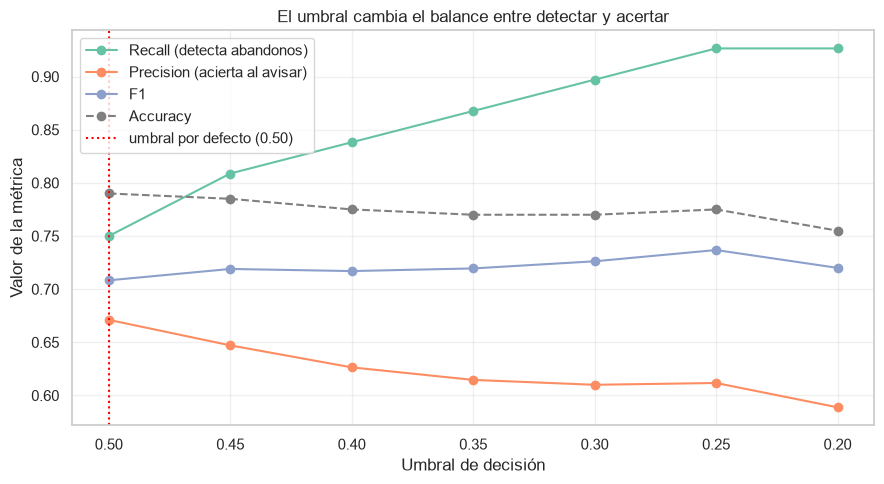

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabla_umbral['umbral'], tabla_umbral['Recall'], marker='o', label='Recall (detecta abandonos)')
ax.plot(tabla_umbral['umbral'], tabla_umbral['Precision'], marker='o', label='Precision (acierta al avisar)')
ax.plot(tabla_umbral['umbral'], tabla_umbral['F1'], marker='o', label='F1')
ax.plot(tabla_umbral['umbral'], tabla_umbral['Accuracy'], marker='o', linestyle='--',
        color='gray', label='Accuracy')
ax.axvline(0.5, color='red', linestyle=':', label='umbral por defecto (0.50)')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Valor de la métrica')
ax.set_title('El umbral cambia el balance entre detectar y acertar')
ax.invert_xaxis(); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Qué muestra.** El umbral por defecto (0.50) deja escapar **17 de los 68 abandonos reales**.

Bajándolo a **0.40**, el Recall sube de 0.750 a 0.838 y los no detectados caen de 17 a **11**, a
cambio de 3 puntos de Accuracy (0.790 → 0.775) y de algo de precisión. A **0.25**, el Recall llega
a 0.927 y quedan solo **5 sin detectar**, con el mejor F1 de toda la tabla (0.7368) y un Accuracy
prácticamente igual al de partida (0.775).

Ese último punto es el interesante: **existe un umbral que detecta muchísimos más abandonos sin
pagar casi nada de Accuracy**. Y ninguna de estas mejoras requirió tocar un solo dato.

## B.5 — Conclusión del diagnóstico

| Hipótesis | Veredicto |
|---|---|
| "Faltó limpiar los nulos" | **Descartada.** 0.4 % de celdas, faltan al azar; eliminarlas empeora levemente (0.790 → 0.780) |
| "Hay que sacar outliers" | **Descartada.** No hay valores erróneos, y los extremos de reclamos/consultas son la señal de abandono |
| "El modelo es débil" | **Descartada.** Un Gradient Boosting da 0.785 contra 0.790 de la Logística: es el techo del dataset |
| "El test de 200 casos es chico" | **Confirmada.** IC 95 % de ±0.056; con CV 10-fold la Logística da 0.826 ± 0.034 |
| "El umbral 0.50 no es el óptimo" | **Confirmada.** A 0.25, el Recall pasa de 0.750 a 0.927 con casi el mismo Accuracy |

**La lección de fondo:** ante métricas que no convencen, el reflejo suele ser "limpiar más los
datos". Acá lo medimos y el reflejo estaba equivocado. El margen real estaba en **cómo evaluamos**
(una sola partición chica en vez de validación cruzada) y en **cómo decidimos** (el umbral), no en
los datos de entrada.

Un R² de 0.95 y un AUC de 0.85 no son malos resultados: son, muy probablemente, casi todo lo que
este dataset tiene para dar.

> **Nota sobre el `ConvergenceWarning`.** La Regresión Logística avisa que `lbfgs` no terminó de
> converger. Es porque las variables entran sin escalar y `cargo_mensual` vale ~100.000 mientras
> `satisfaccion` vale 1–10. Ya aparecía en el TP original. Agregar un `StandardScaler` lo silencia
> y mueve el Accuracy de 0.790 a 0.785 — o sea, no cambia ninguna de las conclusiones de arriba.